In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt


In [2]:

def run_detrended_ewma_backtest(ticker, start_date, end_date, span_short=9, span_long=51):
    # 1. Coleta de Dados Originais
    print(f"Baixando dados para {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        close_prices = df['Close'][ticker]
    else:
        close_prices = df['Close']
        
    data = pd.DataFrame({'Close': close_prices}).dropna()

    # 2. Geração de Sinais (Usando dados reais/não detrended, conforme o texto)
    data['EWMA_Curta'] = data['Close'].ewm(span=span_short, adjust=False).mean()
    data['EWMA_Longa'] = data['Close'].ewm(span=span_long, adjust=False).mean()
    data['Signal'] = np.where(data['EWMA_Curta'] > data['EWMA_Longa'], 1, -1)

    # 3. Cálculo dos Retornos Logarítmicos e do Benchmark
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
    
    # Média do retorno no período (ADC - Average Daily Change em logs)
    mean_log_return = data['Log_Return'].mean()
    
    # 4. Processo de Detrending
    # Subtrai a média do período de cada retorno diário individual
    data['Detrended_Return'] = data['Log_Return'] - mean_log_return

    # 5. Aplicação da Regra na Série Detrended
    # O shift(1) garante que operamos no retorno do dia 't' com a informação do fechamento de 't-1'
    data['Strategy_Detrended_Return'] = data['Signal'].shift(1) * data['Detrended_Return']

    # 6. Avaliação de Desempenho
    data = data.dropna()
    
    # Retorno cumulativo para plotagem (convertendo de log para escala multiplicadora normal)
    # Note que o Benchmark (Mercado Detrended) será 1.0 no final (ou seja, lucro/prejuízo 0%)
    data['Market_Detrended_Cumulative'] = np.exp(data['Detrended_Return'].cumsum())
    data['Strategy_Detrended_Cumulative'] = np.exp(data['Strategy_Detrended_Return'].cumsum())

    # Métricas finais
    anos = len(data) / 252
    retorno_estrat_cumulativo = data['Strategy_Detrended_Cumulative'].iloc[-1] - 1
    retorno_estrat_anual = (data['Strategy_Detrended_Cumulative'].iloc[-1] ** (1 / anos)) - 1
    
    vol_estrat = data['Strategy_Detrended_Return'].std() * np.sqrt(252)
    sharpe_estrat = retorno_estrat_anual / vol_estrat if vol_estrat > 0 else 0

    print("-" * 55)
    print("RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)")
    print("-" * 55)
    print(f"Média Diária Removida (ADC em log): {mean_log_return:.6f}")
    print(f"Retorno Cumulativo da Estratégia:   {retorno_estrat_cumulativo:.2%}")
    print(f"Retorno Anualizado da Estratégia:   {retorno_estrat_anual:.2%}")
    print(f"Volatilidade Anual Estratégia:      {vol_estrat:.2%}")
    print(f"Índice Sharpe (Estratégia):         {sharpe_estrat:.2f}")
    print("-" * 55)
    
    # 7. Visualização
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Market_Detrended_Cumulative'], 
             label='Benchmark Neutro (Mercado sem Tendência)', color='gray', alpha=0.7, linestyle='--')
    plt.plot(data.index, data['Strategy_Detrended_Cumulative'], 
             label=f'Poder Preditivo Puro: EWMA({span_short}/{span_long})', color='darkred')
    
    # Linha do zero (Multiplicador 1.0)
    plt.axhline(y=1.0, color='black', linewidth=1)
    
    plt.title(f"Avaliação de Poder Preditivo via Detrending ({ticker})")
    plt.xlabel("Data")
    plt.ylabel("Multiplicador de Capital (Série Detrended)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return data


Baixando dados para ^BVSP...


/tmp/ipykernel_9106/1384970063.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


-------------------------------------------------------
RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)
-------------------------------------------------------
Média Diária Removida (ADC em log): 0.000188
Retorno Cumulativo da Estratégia:   57.97%
Retorno Anualizado da Estratégia:   3.38%
Volatilidade Anual Estratégia:      24.25%
Índice Sharpe (Estratégia):         0.14
-------------------------------------------------------


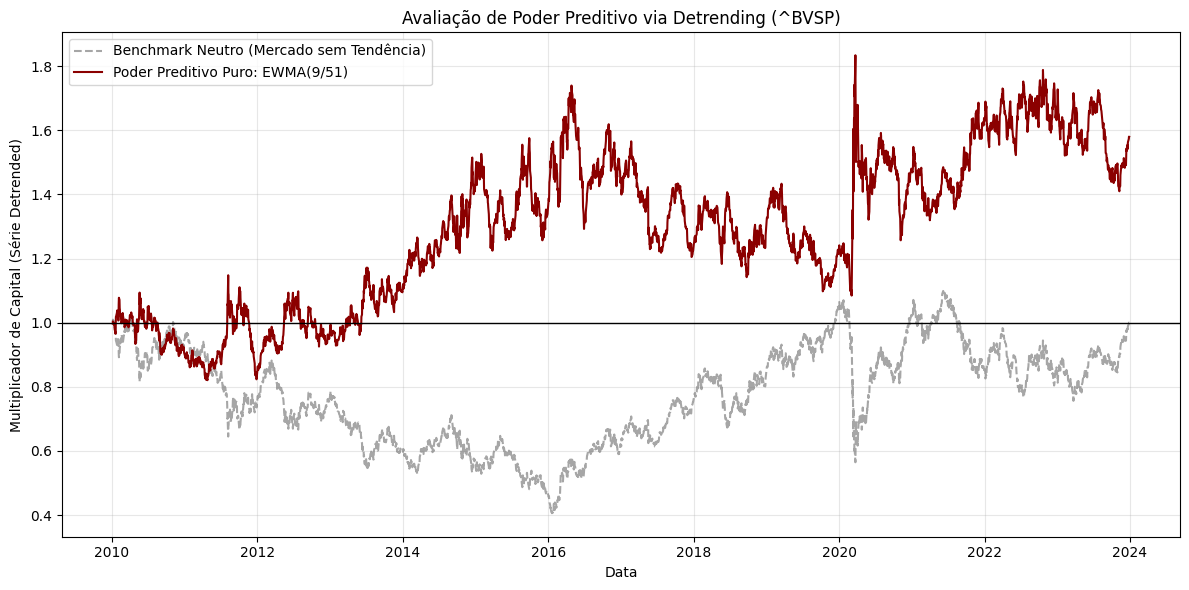

In [3]:

# Execução do script para uma ação e para o índice
# Testando no IBOV como exemplo
df_resultados = run_detrended_ewma_backtest(
    ticker="^BVSP", 
    start_date="2010-01-01", 
    end_date="2024-01-01", 
    span_short=9, 
    span_long=51
)

In [4]:
df_resultados

,Close,EWMA_Curta,EWMA_Longa,Signal,Log_Return,Detrended_Return,Strategy_Detrended_Return,Market_Detrended_Cumulative,Strategy_Detrended_Cumulative
Date,,,,,,,,,
2010-01-05,70240.0,70084.000000,70052.500000,1,0.002780,0.002592,-0.002592,1.002596,0.997411
2010-01-06,70729.0,70213.000000,70078.519231,1,0.006938,0.006750,0.006750,1.009386,1.004166
2010-01-07,70451.0,70260.600000,70092.845414,1,-0.003938,-0.004126,-0.004126,1.005230,1.000032
2010-01-08,70263.0,70261.080000,70099.389821,1,-0.002672,-0.002860,-0.002860,1.002359,0.997176
2010-01-11,70433.0,70295.464000,70112.220982,1,0.002417,0.002229,0.002229,1.004596,0.999401
...,...,...,...,...,...,...,...,...,...
2023-12-21,132182.0,130216.766275,123943.716967,1,0.010480,0.010292,0.010292,0.985813,1.557244
2023-12-22,132753.0,130724.013020,124282.535545,1,0.004310,0.004123,0.004123,0.989885,1.563677
2023-12-26,133533.0,131285.810416,124638.322640,1,0.005858,0.005671,0.005671,0.995515,1.572569


In [5]:

def run_detrended_ewma_backtest(ticker, start_date, end_date, span_short=9, span_long=51):
    # 1. Coleta de Dados Originais
    print(f"Baixando dados para {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    if isinstance(df.columns, pd.MultiIndex):
        close_prices = df['Close'][ticker]
    else:
        close_prices = df['Close']
        
    data = pd.DataFrame({'Close': close_prices}).dropna()

    # 2. Geração de Sinais (Usando dados reais/não detrended, conforme o texto)
    data['EWMA_Curta'] = data['Close'].ewm(span=span_short, adjust=False).mean()
    data['EWMA_Longa'] = data['Close'].ewm(span=span_long, adjust=False).mean()
    data['Signal'] = np.where(data['EWMA_Curta'] > data['EWMA_Longa'], 1, -1)

    # 3. Cálculo dos Retornos Logarítmicos e do Benchmark
    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
    
    # Média do retorno no período (ADC - Average Daily Change em logs)
    mean_log_return = data['Log_Return'].mean()
    
    # 4. Processo de Detrending
    # Subtrai a média do período de cada retorno diário individual
    data['Detrended_Return'] = data['Log_Return'] - mean_log_return

    # 5. Aplicação da Regra na Série Detrended
    # O shift(1) garante que operamos no retorno do dia 't' com a informação do fechamento de 't-1'
    data['Strategy_Detrended_Return'] = data['Signal'].shift(1) * data['Detrended_Return']

    # 6. Avaliação de Desempenho
    data = data.dropna()
    
    # Retorno cumulativo para plotagem (convertendo de log para escala multiplicadora normal)
    # Note que o Benchmark (Mercado Detrended) será 1.0 no final (ou seja, lucro/prejuízo 0%)
    data['Market_Detrended_Cumulative'] = np.exp(data['Detrended_Return'].cumsum())
    data['Strategy_Detrended_Cumulative'] = np.exp(data['Strategy_Detrended_Return'].cumsum())

    # Métricas finais
    anos = len(data) / 252
    retorno_estrat_cumulativo = data['Strategy_Detrended_Cumulative'].iloc[-1] - 1
    retorno_estrat_anual = (data['Strategy_Detrended_Cumulative'].iloc[-1] ** (1 / anos)) - 1
    
    vol_estrat = data['Strategy_Detrended_Return'].std() * np.sqrt(252)
    sharpe_estrat = retorno_estrat_anual / vol_estrat if vol_estrat > 0 else 0

    print("-" * 55)
    print("RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)")
    print("-" * 55)
    print(f"Média Diária Removida (ADC em log): {mean_log_return:.6f}")
    print(f"Retorno Cumulativo da Estratégia:   {retorno_estrat_cumulativo:.2%}")
    print(f"Retorno Anualizado da Estratégia:   {retorno_estrat_anual:.2%}")
    print(f"Volatilidade Anual Estratégia:      {vol_estrat:.2%}")
    print(f"Índice Sharpe (Estratégia):         {sharpe_estrat:.2f}")
    print("-" * 55)
    
    # 7. Visualização
    plt.figure(figsize=(12, 6))
    plt.plot(data.index, data['Market_Detrended_Cumulative'], 
             label='Benchmark Neutro (Mercado sem Tendência)', color='gray', alpha=0.7, linestyle='--')
    plt.plot(data.index, data['Strategy_Detrended_Cumulative'], 
             label=f'Poder Preditivo Puro: EWMA({span_short}/{span_long})', color='darkred')
    
    # Linha do zero (Multiplicador 1.0)
    plt.axhline(y=1.0, color='black', linewidth=1)
    
    plt.title(f"Avaliação de Poder Preditivo via Detrending ({ticker})")
    plt.xlabel("Data")
    plt.ylabel("Multiplicador de Capital (Série Detrended)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return data


Baixando dados para ^BVSP...
-------------------------------------------------------
RESULTADOS DO BACKTEST (SÉRIE COM TENDÊNCIA ZERO)
-------------------------------------------------------
Média Diária Removida (ADC em log): 0.000188
Retorno Cumulativo da Estratégia:   57.97%
Retorno Anualizado da Estratégia:   3.38%
Volatilidade Anual Estratégia:      24.25%
Índice Sharpe (Estratégia):         0.14
-------------------------------------------------------


/tmp/ipykernel_9106/1384970063.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date, progress=False)


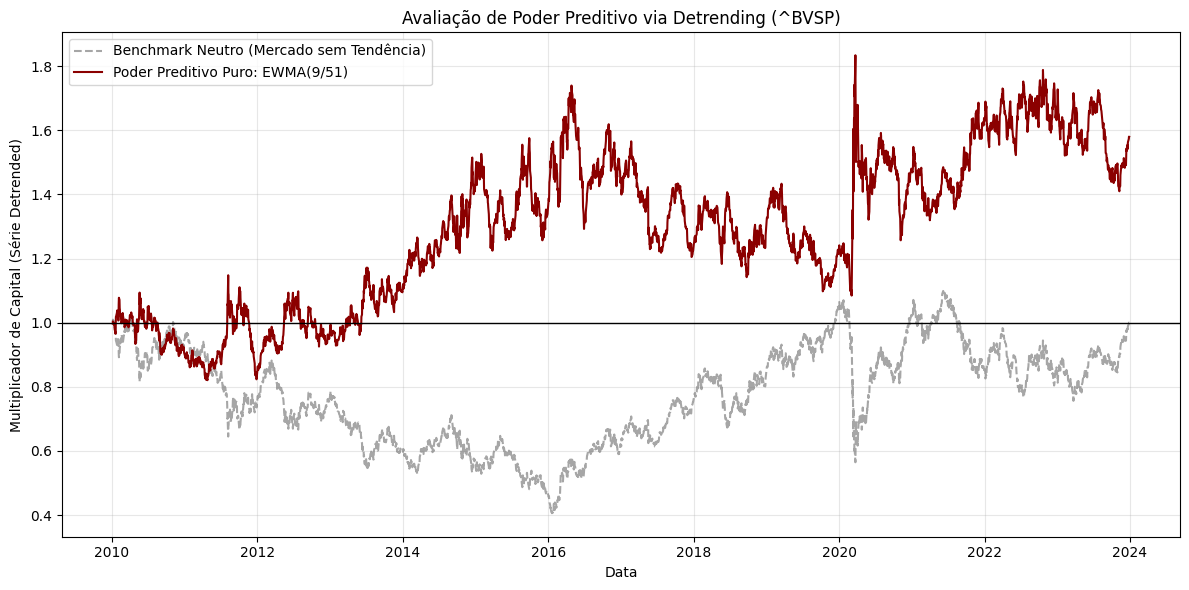

In [6]:
df_resultados = run_detrended_ewma_backtest(
        ticker="^BVSP", 
        start_date="2010-01-01", 
        end_date="2024-01-01", 
        span_short=9, 
        span_long=51
    )